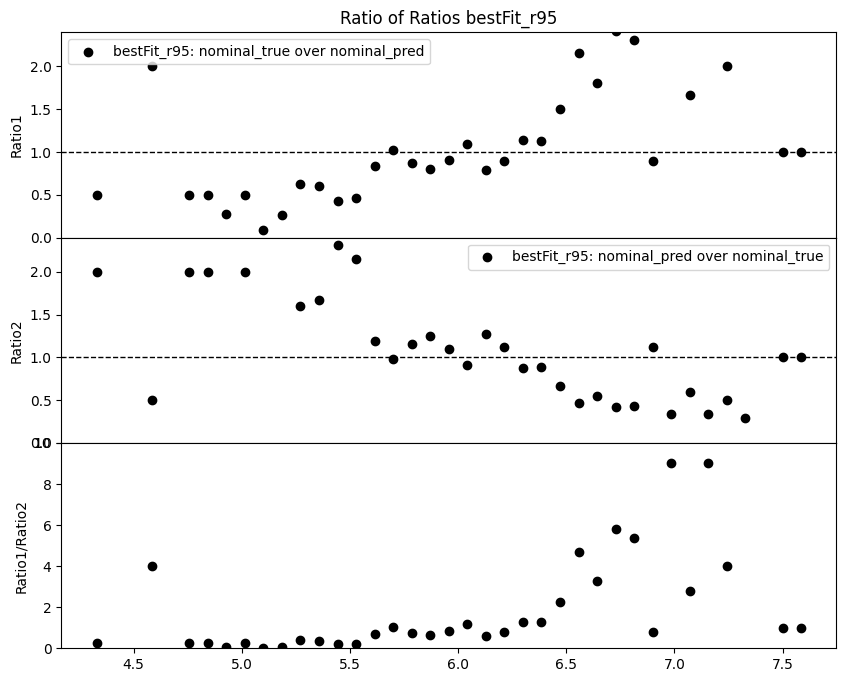

In [6]:
import numpy as np
import plot_labels
import hist
import matplotlib.pyplot as plt


def plot_hist_ratio(data, metric, numerator, denominator, sig=None):
    '''
    Generic plotting utility for making histogram ratio comparison plots.
    hist1 and hist2 must be 1d arrays of data to be turned into histograms
    formatText is a dict containing all graphs strings for formatting. 
    If anything isnt present, it will default to a generic string.
    '''
    # 
    # If defined, the plot is centered on the average and given sig stds away on either side
    # Reccommended to use sig=3 or more, typically sig=5 if theres little outliers
    # compare can be set to either "pred" or "true" if we want to compare either the truths or the preds for the two data sets
    # Extract necessary data

    data1 = data[numerator[0]][f"{metric}_{numerator[1]}"]
    data2 = data[denominator[0]][f"{metric}_{denominator[1]}"]

    #These should always be binned along the layer index
    if metric == "firstLayer" or metric == "maxELayer" or metric == "coe_layers": 
        sig = None
    
    formatText = plot_labels.plot_labels_select(metric, numerator, denominator)

    # binning
    avg = np.mean([np.mean(data1), np.mean(data2)]) # Plots center of both hists
    std = np.mean([np.std(data1),np.std(data2)])

    #auto borders
    if sig==0:
        upper = np.max(np.concatenate((data1,data2)))
        lower = np.min(np.concatenate((data1,data2)))
        hist_1 = hist.Hist(
            hist.axis.Regular(
                100, lower-0.5*std, upper+0.5*std, # add a buffer to the bounds
                label=formatText["x_axis"], underflow=False, overflow=False
            )
        ).fill(data1)

        hist_2 = hist.Hist(
            hist.axis.Regular(
                100, lower-0.5*std, upper+0.5*std,
                label=formatText["x_axis"], underflow=False, overflow=False
            )
        ).fill(data2)
    #hand set borders
    elif sig==None:
        hist_1 = hist.Hist(
            hist.axis.Regular(
                formatText["bins"], formatText["lower"], formatText["upper"],
                label=formatText["x_axis"], underflow=False, overflow=False
            )
        ).fill(data1)

        hist_2 = hist.Hist(
            hist.axis.Regular(
                formatText["bins"], formatText["lower"], formatText["upper"],
                label=formatText["x_axis"], underflow=False, overflow=False
            )
        ).fill(data2)
    #centered, #sig on either side
    else:
        hist_1 = hist.Hist(
            hist.axis.Regular(
                100, avg-sig*std, avg+sig*std,
                label=formatText["x_axis"], underflow=False, overflow=False
            )
        ).fill(data1)

        hist_2 = hist.Hist(
            hist.axis.Regular(
                100, avg-sig*std, avg+sig*std,
                label=formatText["x_axis"], underflow=False, overflow=False
            )
        ).fill(data2)


    fig = plt.figure(figsize=(10, 8))
    fig.tight_layout()
    plt.title(formatText["title"])
    plt.axis("off") #When adding a title, it draws an entire figure, We only want the title
    
    main_ax_artists, sublot_ax_arists = hist_1.plot_ratio(
        hist_2,
        rp_ylabel=formatText["y_axis"],
        rp_ybound=[0,2.5],
        rp_num_label=f"{formatText['label1']}, $\mu$ {np.mean(data1):.2f}, $\sigma$ {np.std(data1):.2f}",
        rp_denom_label=f"{formatText['label2']}, $\mu$ {np.mean(data2):.2f}, $\sigma$ {np.std(data2):.2f}\n{len(data1)} events plotted",
        rp_uncert_draw_type="bar",  # line or bar
        
    )
    
    # fig.savefig(formatText["saveas"])
    plt.close()
    return

#=================================================================================================
#=================================================================================================
#=================================================================================================
#=================================================================================================
#=================================================================================================
#=================================================================================================

def plot_ratio(data, metric, numerator, denominator, sig=None):
        
    data1 = data[numerator[0]][f"{metric}_{numerator[1]}"]
    data2 = data[denominator[0]][f"{metric}_{denominator[1]}"]
    formatText = plot_labels.plot_labels_select(metric, numerator, denominator)

    # binning
    avg = np.mean([np.mean(data1), np.mean(data2)]) # Plots center of both hists
    std = np.mean([np.std(data1),np.std(data2)])

    # histy1, histx1 = np.histogram(data1, bins = formatText["bins"], range = [formatText["lower"], formatText["upper"]])
    # histy2, histx2 = np.histogram(data2, bins = formatText["bins"], range = [formatText["lower"], formatText["upper"]])
    


    fig, axs = plt.subplots(nrows=2, figsize=(10,8), sharex=True, gridspec_kw={"hspace":0,"height_ratios":[3,1]})
    
    # axs[0].bar(histx1[1:], histy1, width=(formatText["upper"]-formatText["lower"])/formatText["bins"], 
    #             yerr = hist1err, align = "edge", color="blue", ecolor="blue", fill = False,
    #             label = f"{formatText['label1']}, $\mu$ {np.mean(data1):.2f}, $\sigma$ {np.std(data1):.2f}")
    # axs[0].bar(histx2[1:], histy2, width=(formatText["upper"]-formatText["lower"])/formatText["bins"], 
    #             yerr = hist2err, align = "edge", color="orange", ecolor="orange", fill = False,
    #             label = f"{formatText['label2']}, $\mu$ {np.mean(data2):.2f}, $\sigma$ {np.std(data2):.2f}\n{len(data1)} events plotted")


    #Top plot
    histy1, histx1,_ = axs[0].hist(data1, bins = formatText["bins"], histtype="step",
                                range = [formatText["lower"],formatText["upper"]],
                                label = f"{formatText['label1']}, $\mu$ {np.mean(data1):.2f}, $\sigma$ {np.std(data1):.2f}",
                                color="blue")
    histy2, histx2,_ = axs[0].hist(data2, bins = formatText["bins"], histtype="step",
                                range = [formatText["lower"],formatText["upper"]],
                                label = f"{formatText['label2']}, $\mu$ {np.mean(data2):.2f}, $\sigma$ {np.std(data2):.2f}\n{len(data1)} events plotted",
                                color="orange")

    #histErrors
    x_centers = np.asarray( [(x + histx1[i - 1])/2 for i, x in enumerate(histx1) if i > 0] )
    hist1err = np.sqrt(histy1)
    hist2err = np.sqrt(histy2)

    axs[0].errorbar(x_centers, histy1, hist1err, color="blue", ls="none")
    axs[0].errorbar(x_centers, histy2, hist2err, color="orange", ls="none")

    #Ratio plot
    ratiox = x_centers
    ratioy = np.asarray( [histy1[i]/histy2[i] if histy1[i] != 0 and histy2[i] != 0 else -1 for i in range(len(histy1))] ) #This is how its always meant to be
    #hist output and division is always >= 0 so use -1 as filter flag
    ratiox = ratiox[ratioy!=-1]
    hist1err = hist1err[ratioy!=-1]
    hist2err = hist2err[ratioy!=-1] 
    ratioy = ratioy[ratioy!=-1]
    ratioerr = (ratioy * np.sqrt(hist1err**-1 + hist2err**-1))
    
    axs[1].scatter(ratiox,ratioy, color="black")
    axs[1].errorbar(ratiox,ratioy, ratioerr, color="black", ls="none")
    axs[1].axhline(y=1, linestyle="--", linewidth="1", color="black")

    #Format
    axs[0].set_title(formatText["title"])
    axs[1].set_xlabel(formatText["x_axis"])
    axs[0].set_ylabel("Count")
    axs[1].set_ylabel("Ratio")
    axs[0].legend()
    axs[1].set_ylim(0,2.4)

    # fig.savefig(f"best{denominator[0]}{denominator[1]}"+formatText["saveas"])
    # plt.show()
    plt.close()
            
    return ratiox, ratioy


def rofR(ratio1, ratio2, metric, ratioName1, ratioName2):
    ratio1x = ratio1[0]
    ratio1y = ratio1[1]
    ratio2x = ratio2[0]
    ratio2y = ratio2[1]

    fig, axs = plt.subplots(nrows=3, figsize=(10,8), sharex=True, gridspec_kw={"hspace":0})

    formatText = plot_labels.plot_labels_select(metric, ratioName1[0], ratioName1[1])

    axs[0].scatter(ratio1x,ratio1y, color="black",
                   label=f"{metric}: {ratioName1[0][0]}_{ratioName1[0][1]} over {ratioName1[1][0]}_{ratioName1[1][1]}")
    axs[0].axhline(y=1, linestyle="--", linewidth="1", color="black")
    
    axs[1].scatter(ratio2x,ratio2y, color="black",
                   label=f"{metric}: {ratioName2[0][0]}_{ratioName2[0][1]} over {ratioName2[1][0]}_{ratioName2[1][1]}")
    axs[1].axhline(y=1, linestyle="--", linewidth="1", color="black")


    #ratio of ratios section
    # print(len(ratio1x), len(ratio2x))
    # print(ratio1x, ratio2x)
    shared = list(set(ratio1x) & set(ratio2x))
    ratioratio = []
    for x in shared:
        i = np.where(ratio1x == x)[0]
        j = np.where(ratio2x == x)[0]
        ratioratio.append(ratio1y[i]/ratio2y[j])
    # print(len(shared), shared)

    axs[2].scatter(shared,ratioratio, color="black")
    # axs[2].axhline(y=1, linestyle="--", linewidth="1", color="black")

    
    axs[0].set_title(f"Ratio of Ratios {metric}")
    axs[1].set_xlabel(formatText["x_axis"])
    axs[0].set_ylabel("Ratio1")
    axs[1].set_ylabel("Ratio2")
    axs[2].set_ylabel("Ratio1/Ratio2")
    axs[0].legend()
    axs[1].legend()
    axs[0].set_ylim(0,2.4)
    axs[1].set_ylim(0,2.4)
    axs[2].set_ylim(0,10)
    


    # fig.savefig(f"beRatioOfRatios"+formatText["saveas"])
    plt.show()
    plt.close()



def main():

    results = {}
    results["nominal"] = {"bestFit_r95_true": np.random.normal(6.2,0.5,1000),
                          "bestFit_r95_pred": np.random.normal(6,0.5,1000)}
    # plot_hist_ratio(results, "bestFit_r95", ("nominal","true"), ("nominal","pred"))
    ratio1 = plot_ratio(results, "bestFit_r95", ("nominal","true"), ("nominal","pred"))
    ratio2 = plot_ratio(results, "bestFit_r95", ("nominal","pred"), ("nominal","true"))
    rofR(ratio1,ratio2, "bestFit_r95", (("nominal","true"), ("nominal","pred")), (("nominal","pred"), ("nominal","true")) )

if __name__=="__main__":
    main()